In [1]:
# ============================================
# NOTEBOOK 5: MODEL EVALUATION & SHAP
# Understanding WHY the model predicts churn
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc, confusion_matrix
from xgboost import XGBClassifier

sns.set_style("whitegrid")

# ── Reload and prepare data ──────────────────
df = pd.read_csv('../data/churn_cleaned.csv')
X = pd.get_dummies(df.drop('Churn', axis=1), drop_first=True)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ── Retrain XGBoost ──────────────────────────
xgb_model = XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)
xgb_model.fit(X_train, y_train)
xgb_predictions = xgb_model.predict(X_test)

print("Everything loaded and model trained")

Everything loaded and model trained


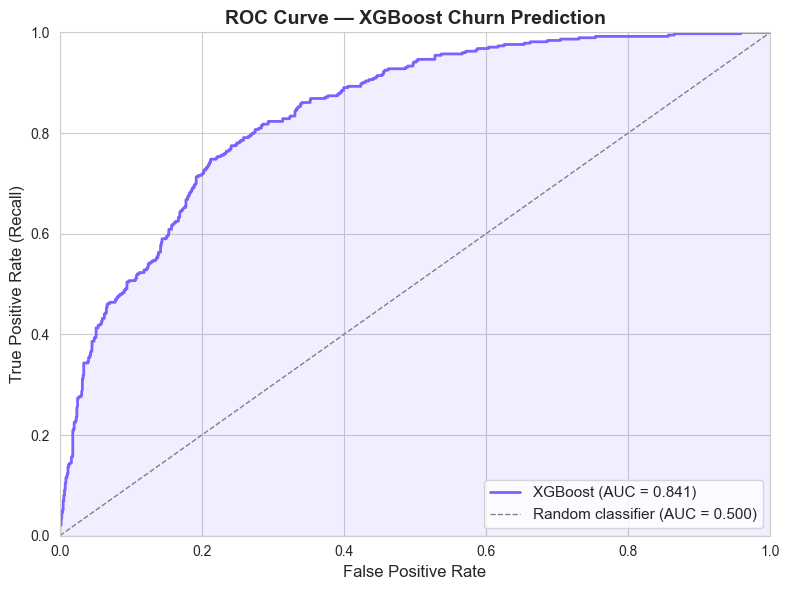

AUC Score: 0.841
ROC curve saved


In [2]:
# ============================================
# ROC CURVE & AUC SCORE
# Shows how well the model separates churners
# from non-churners at different thresholds
# ============================================

# Get probability predictions (not just 0/1)
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]

# Calculate ROC curve points
fpr, tpr, thresholds = roc_curve(y_test, xgb_probs)
roc_auc = auc(fpr, tpr)

# Plot
fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(fpr, tpr, color='#7b61ff', linewidth=2,
        label=f'XGBoost (AUC = {roc_auc:.3f})')
ax.plot([0, 1], [0, 1], color='grey', linewidth=1,
        linestyle='--', label='Random classifier (AUC = 0.500)')

ax.fill_between(fpr, tpr, alpha=0.1, color='#7b61ff')

ax.set_title('ROC Curve — XGBoost Churn Prediction',
             fontsize=14, fontweight='bold')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=12)
ax.legend(fontsize=11)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

plt.tight_layout()
plt.savefig('../reports/roc_curve.png', dpi=150)
plt.show()

print(f"AUC Score: {roc_auc:.3f}")
print("ROC curve saved")

In [3]:
# ============================================
# SHAP VALUES
# Explains WHY the model makes each prediction
# Which features push customers toward churning?
# ============================================

print("Calculating SHAP values...")

# Create SHAP explainer for XGBoost
explainer = shap.TreeExplainer(xgb_model)

# Calculate SHAP values for test set
shap_values = explainer.shap_values(X_test)

print("SHAP values calculated")
print("Shape of SHAP values:", shap_values.shape)

Calculating SHAP values...
SHAP values calculated
Shape of SHAP values: (1409, 30)


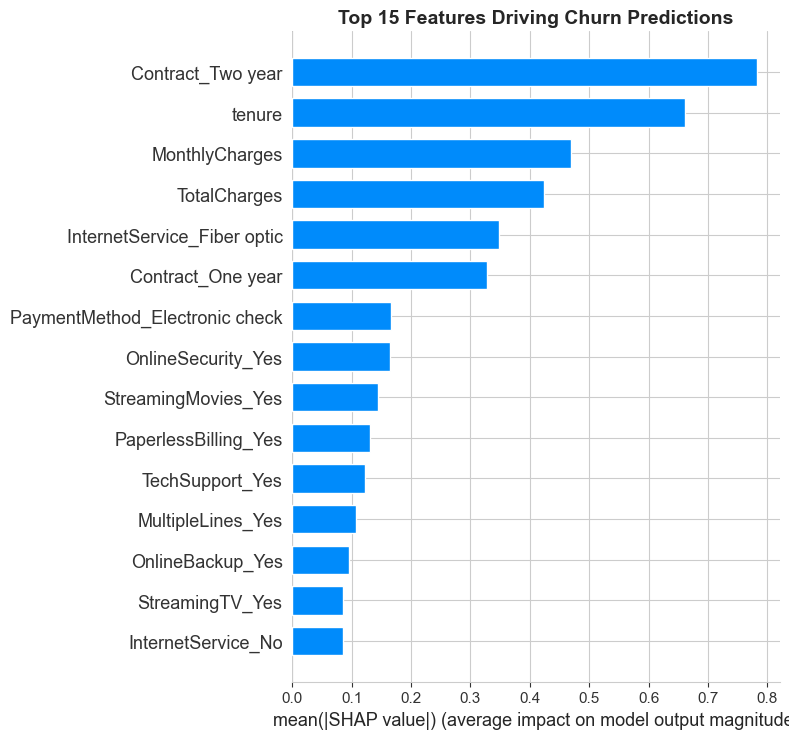

SHAP chart saved


In [4]:
# ============================================
# SHAP SUMMARY PLOT
# Shows the top features driving churn
# Red = pushes toward churn
# Blue = pushes away from churn
# ============================================

fig, ax = plt.subplots(figsize=(10, 8))

shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar",
    max_display=15,
    show=False
)

plt.title('Top 15 Features Driving Churn Predictions',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/shap_feature_importance.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("SHAP chart saved")

In [5]:
# ============================================
# IDENTIFY TOP 5 CHURN DRIVERS
# The features with highest average impact
# ============================================

# Calculate mean absolute SHAP value per feature
shap_importance = pd.DataFrame({
    'feature': X_test.columns,
    'importance': np.abs(shap_values).mean(axis=0)
}).sort_values('importance', ascending=False)

print("TOP 10 FEATURES DRIVING CHURN:")
print("=" * 45)
for i, row in shap_importance.head(10).iterrows():
    bar = "█" * int(row['importance'] * 100)
    print(f"{row['feature']:<35} {row['importance']:.4f}  {bar}")

TOP 10 FEATURES DRIVING CHURN:
Contract_Two year                   0.7822  ██████████████████████████████████████████████████████████████████████████████
tenure                              0.6606  ██████████████████████████████████████████████████████████████████
MonthlyCharges                      0.4696  ██████████████████████████████████████████████
TotalCharges                        0.4237  ██████████████████████████████████████████
InternetService_Fiber optic         0.3487  ██████████████████████████████████
Contract_One year                   0.3272  ████████████████████████████████
PaymentMethod_Electronic check      0.1667  ████████████████
OnlineSecurity_Yes                  0.1645  ████████████████
StreamingMovies_Yes                 0.1440  ██████████████
PaperlessBilling_Yes                0.1316  █████████████


In [6]:
summary = """
 SUMMARY — Model Evaluation & SHAP Analysis
=================================================

ROC CURVE RESULTS:
- AUC Score: 0.841
- Interpretation: GOOD — model clearly separates
  churners from non-churners
- Significantly better than random (0.500 baseline)

TOP 5 CHURN DRIVERS (SHAP Analysis):
1. Contract_Two year    — strongest retention factor
2. Tenure               — loyalty protects against churn
3. MonthlyCharges       — high bills drive churn
4. TotalCharges         — related to tenure/loyalty
5. InternetService_Fibre optic — fibre customers at risk

BUSINESS RECOMMENDATIONS FROM SHAP:
1. Prioritise converting customers to 2-year contracts
2. Focus retention efforts on months 1-12 (low tenure)
3. Review pricing for high monthly charge customers
4. Investigate fibre optic service quality/pricing
5. Use these 5 features to build targeted campaigns

KEY ACHIEVEMENT:
Model explains not just WHO will churn but WHY —
turning a black-box prediction into actionable
business intelligence.
"""
print(summary)


 SUMMARY — Model Evaluation & SHAP Analysis

ROC CURVE RESULTS:
- AUC Score: 0.841
- Interpretation: GOOD — model clearly separates
  churners from non-churners
- Significantly better than random (0.500 baseline)

TOP 5 CHURN DRIVERS (SHAP Analysis):
1. Contract_Two year    — strongest retention factor
2. Tenure               — loyalty protects against churn
3. MonthlyCharges       — high bills drive churn
4. TotalCharges         — related to tenure/loyalty
5. InternetService_Fibre optic — fibre customers at risk

BUSINESS RECOMMENDATIONS FROM SHAP:
1. Prioritise converting customers to 2-year contracts
2. Focus retention efforts on months 1-12 (low tenure)
3. Review pricing for high monthly charge customers
4. Investigate fibre optic service quality/pricing
5. Use these 5 features to build targeted campaigns

KEY ACHIEVEMENT:
Model explains not just WHO will churn but WHY —
turning a black-box prediction into actionable
business intelligence.

